# Hệ thống dự đoán bệnh tiểu đường

Assignment 01 - Intelligent Systems

## 5. Biểu diễn dữ liệu

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_PATH = Path("diabetes.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy tệp dữ liệu: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df_raw = df.copy()

print(f"Đã đọc dữ liệu từ: {DATA_PATH.resolve()}")
df.info()


Đã đọc dữ liệu từ: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/data/diabet_datasets/diabetes.csv
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [2]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 6. Phân tích đặc trưng và biến mục tiêu

In [3]:
print("Nulls")
print("=====")
print(df.isnull().sum())


Nulls
=====
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
display(df_raw[["Glucose", "BMI", "Age", "Outcome"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
Glucose,768.0,121.677083,30.464161,44.0,99.75,117.00,140.25,199.0
BMI,768.0,32.434635,6.880498,18.2,27.50,32.05,36.60,67.1
Age,768.0,33.240885,11.760232,21.0,24.00,29.00,41.00,81.0
Outcome,768.0,0.348958,0.476951,0.0,0.00,0.00,1.00,1.0


In [5]:
# Kiểm tra giá trị 0 bất thường
print("Giá trị 0 theo từng cột:")
print("========================")
print(df.eq(0).sum())


Giá trị 0 theo từng cột:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


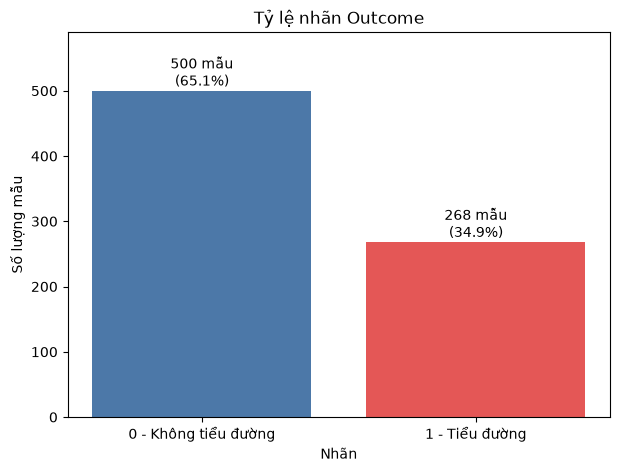

In [6]:
# Biểu đồ tỷ lệ nhãn Outcome
import matplotlib.pyplot as plt

label_counts = df["Outcome"].value_counts().sort_index()
label_percentages = label_counts / label_counts.sum() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(
    ["0 - Không tiểu đường", "1 - Tiểu đường"],
    label_counts.values,
    color=["#4C78A8", "#E45756"]
)
plt.title("Tỷ lệ nhãn Outcome")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng mẫu")
for bar, count, percentage in zip(bars, label_counts.values, label_percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{count} mẫu\n({percentage:.1f}%)",
        ha="center"
    )
plt.ylim(0, label_counts.max() * 1.18)
plt.show()


Nhận thấy bộ dữ liệu này là bộ dữ liệu thiên lệch nhẹ, với tỉ lệ nhãn 0 gần gấp 2 nhãn 1.

In [7]:
# Thay giá trị 0 bất thường bằng NaN rồi impute bằng mean
columns_with_invalid_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

df[columns_with_invalid_zeros] = df[columns_with_invalid_zeros].replace(0, np.nan)
df.fillna(df.mean(), inplace=True)

print("Sau khi xử lý giá trị 0:")
print(df.eq(0).sum())


Sau khi xử lý giá trị 0:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


## 7. Phân tích khám phá dữ liệu (EDA)

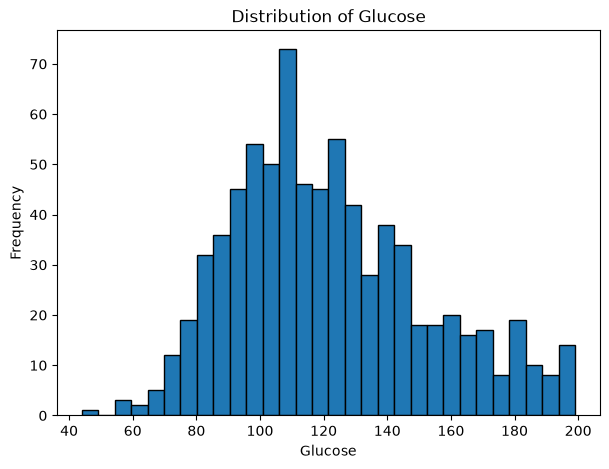

In [8]:
# Biểu đồ phân phối Glucose
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.hist(df['Glucose'], bins=30, edgecolor='black')
plt.title('Distribution of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()


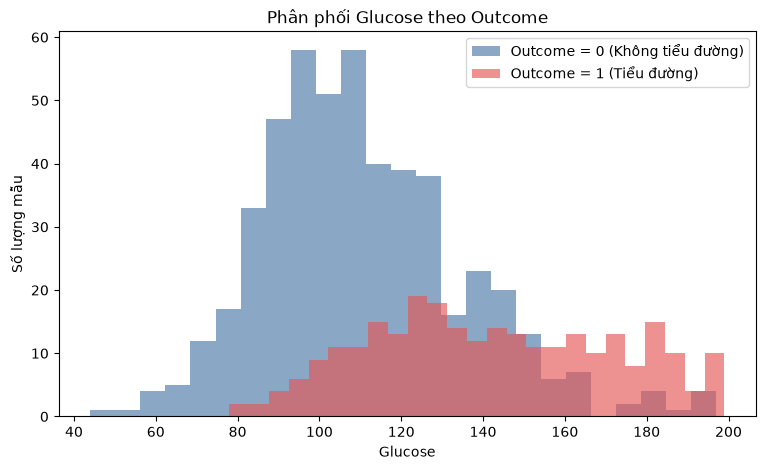

In [9]:
# Phân phối Glucose theo Outcome
plt.figure(figsize=(9, 5))
plt.hist(
    df_raw.loc[df_raw["Outcome"] == 0, "Glucose"],
    bins=25, alpha=0.65,
    label="Outcome = 0 (Không tiểu đường)", color="#4C78A8"
)
plt.hist(
    df_raw.loc[df_raw["Outcome"] == 1, "Glucose"],
    bins=25, alpha=0.65,
    label="Outcome = 1 (Tiểu đường)", color="#E45756"
)
plt.title("Phân phối Glucose theo Outcome")
plt.xlabel("Glucose")
plt.ylabel("Số lượng mẫu")
plt.legend()
plt.show()


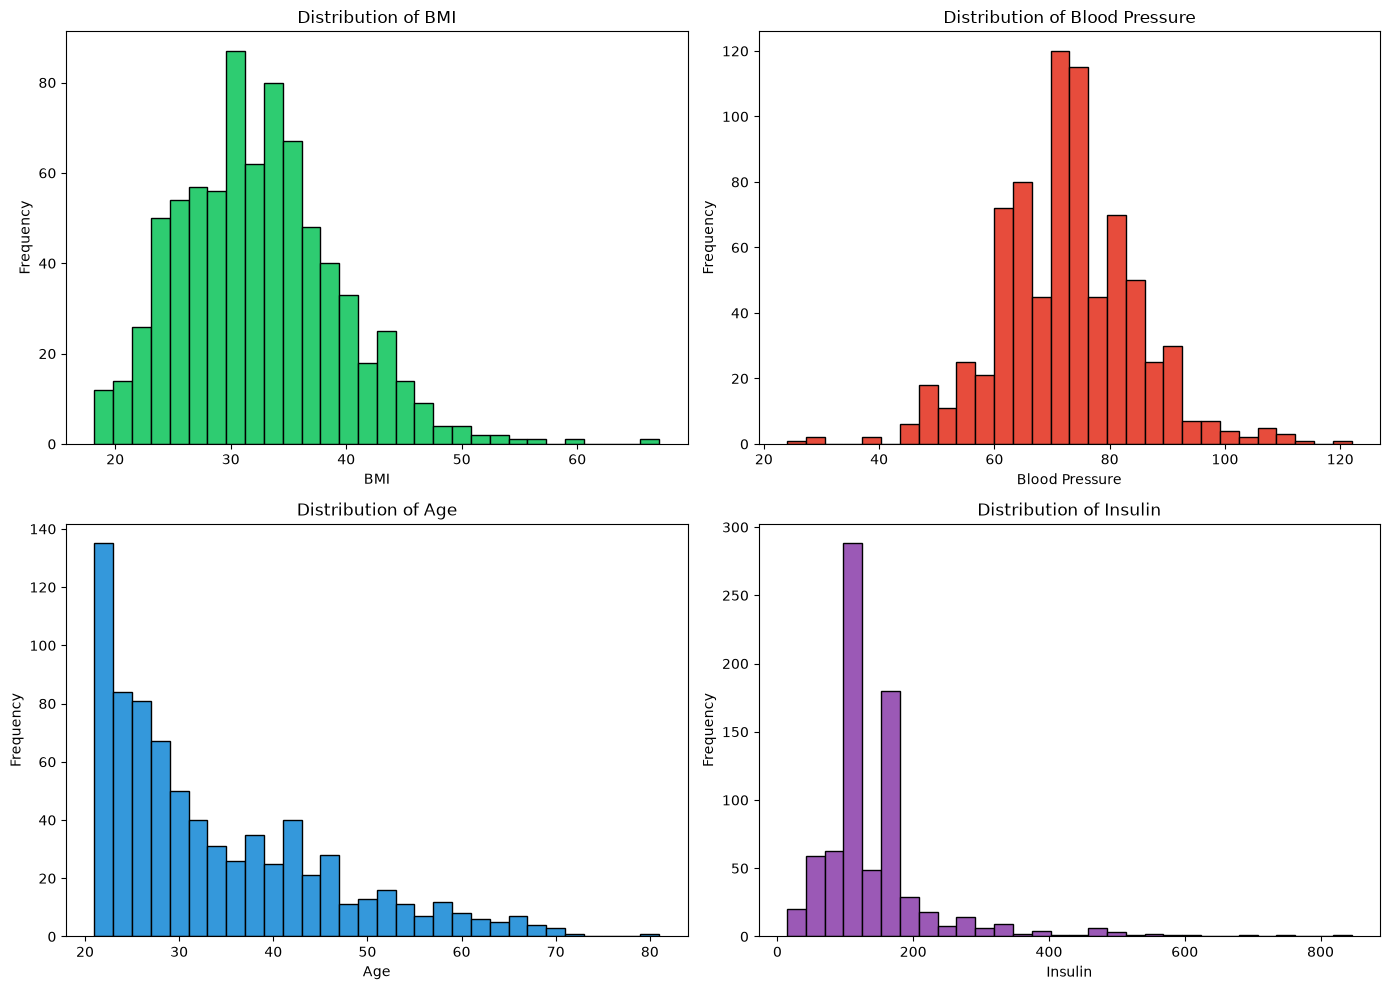

In [10]:
# Biểu đồ phân phối BMI, BloodPressure, Age, Insulin
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['BMI'], bins=30, edgecolor='black', color='#2ecc71')
axes[0, 0].set_title('Distribution of BMI')
axes[0, 0].set_xlabel('BMI')

axes[0, 1].hist(df['BloodPressure'], bins=30, edgecolor='black', color='#e74c3c')
axes[0, 1].set_title('Distribution of Blood Pressure')
axes[0, 1].set_xlabel('Blood Pressure')

axes[1, 0].hist(df['Age'], bins=30, edgecolor='black', color='#3498db')
axes[1, 0].set_title('Distribution of Age')
axes[1, 0].set_xlabel('Age')

axes[1, 1].hist(df['Insulin'], bins=30, edgecolor='black', color='#9b59b6')
axes[1, 1].set_title('Distribution of Insulin')
axes[1, 1].set_xlabel('Insulin')

for ax in axes.flat:
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


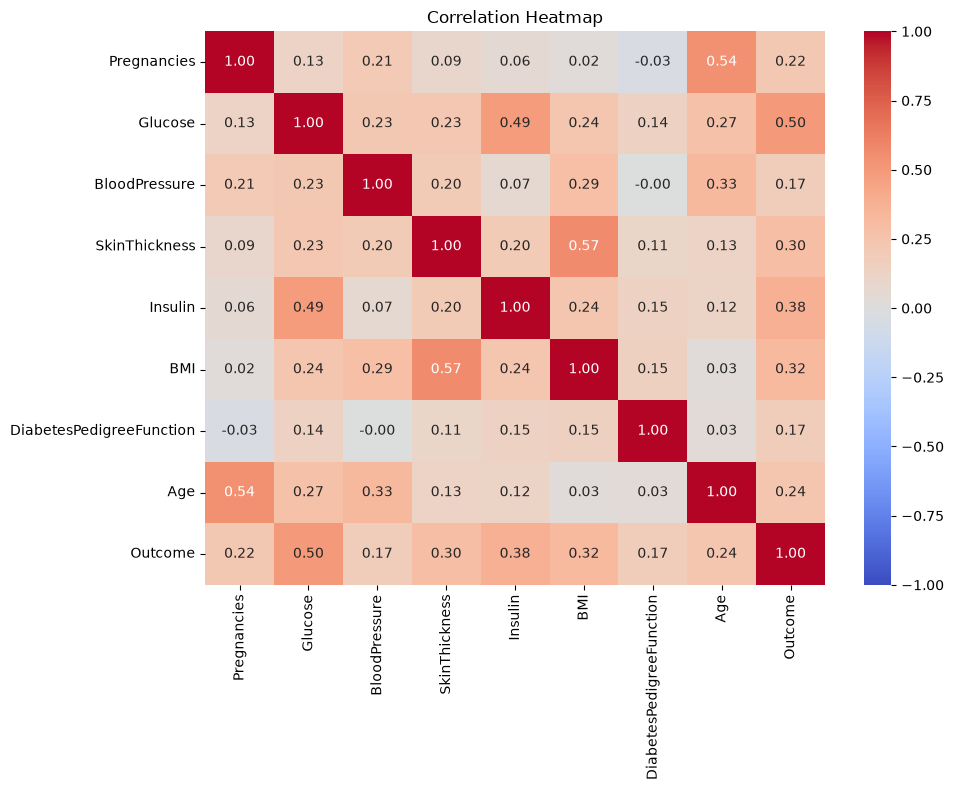

In [11]:
# Ma trận tương quan
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [12]:
# Chọn top features có tương quan cao nhất với Outcome
print(df.corr(numeric_only=True).nlargest(7, 'Outcome')['Outcome'])


Outcome          1.000000
Glucose          0.495990
Insulin          0.377081
BMI              0.315577
SkinThickness    0.295138
Age              0.238356
Pregnancies      0.221898
Name: Outcome, dtype: float64


Từ ma trận tương quan, Glucose có tương quan dương mạnh nhất với Outcome (r ≈ 0.49), tiếp theo là BMI (r ≈ 0.31) và Age (r ≈ 0.24). Chọn 3 feature cơ sở: Glucose, BMI, Age.

## 8. Chia tập huấn luyện/kiểm tra (cơ sở dựa trên 3 feature)

In [13]:
from sklearn.model_selection import train_test_split

FEATURE_COLUMNS = ["Glucose", "BMI", "Age"]
TARGET_COLUMN = "Outcome"

X_raw, y = df[FEATURE_COLUMNS], df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Tập huấn luyện: {X_train.shape}; Tập kiểm tra: {X_test.shape}")
print("Các cột của X_train:", X_train.columns.tolist())
print("Số feature:", X_train.shape[1])


Tập huấn luyện: (614, 3); Tập kiểm tra: (154, 3)
Các cột của X_train: ['Glucose', 'BMI', 'Age']
Số feature: 3


## 9. Mô hình cơ sở (Baseline)

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import seaborn as sns

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

display(pd.DataFrame([{
    "Model": "Mô hình cơ sở (lớp xuất hiện nhiều nhất)",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1-score": f1_score(y_test, baseline_pred, zero_division=0),
}]))


,Model,Accuracy,Precision,Recall,F1-score
0,Mô hình cơ sở (lớp xuất hiện nhiều nhất),0.649351,0.0,0.0,0.0


Baseline luôn dự đoán lớp 0 (không tiểu đường). Accuracy khoảng 65% nhưng Precision, Recall, F1-score của lớp 1 đều bằng 0. Các mô hình phải vượt được mốc này.

## 10. Mô hình 1 — Hồi quy Logistic

,Train,Test
Accuracy,0.783388,0.707792
Precision,0.742515,0.595745
Recall,0.579439,0.518519
F1-score,0.650919,0.554455


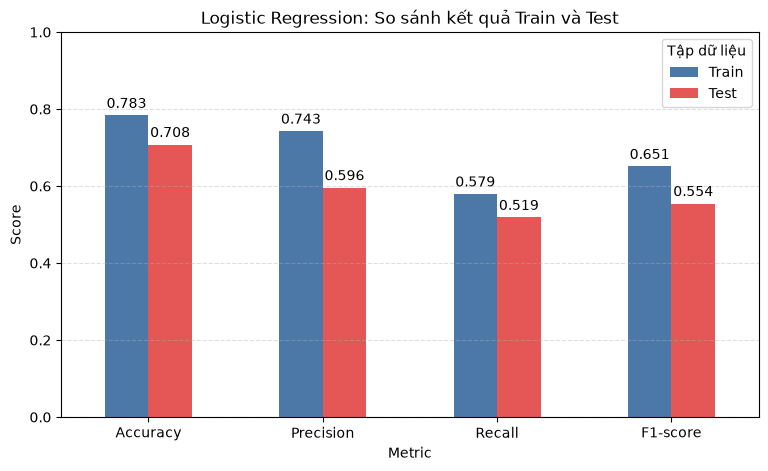

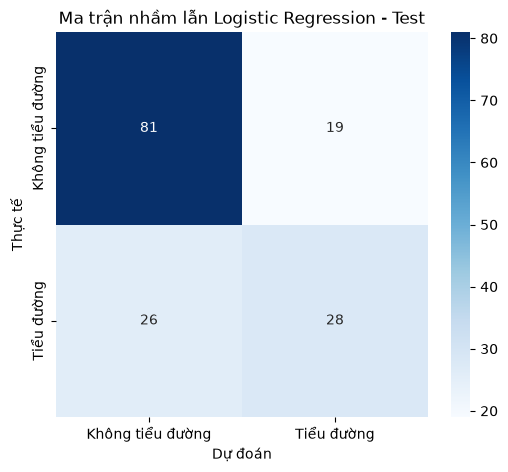

In [15]:
from sklearn.linear_model import LogisticRegression

results = []

log_regress = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
log_regress.fit(X_train, y_train)

y_train_pred = log_regress.predict(X_train)
y_test_pred = log_regress.predict(X_test)

metrics_df = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])
display(metrics_df)

# Biểu đồ Train - Test
ax = metrics_df.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("Logistic Regression: So sánh kết quả Train và Test")
plt.xlabel("Metric"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0); plt.legend(title="Tập dữ liệu")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Không tiểu đường", "Tiểu đường"],
    yticklabels=["Không tiểu đường", "Tiểu đường"])
plt.title("Ma trận nhầm lẫn Logistic Regression - Test")
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.show()

accuracy = metrics_df.loc["Accuracy", "Test"]
precision = metrics_df.loc["Precision", "Test"]
recall = metrics_df.loc["Recall", "Test"]
f1 = metrics_df.loc["F1-score", "Test"]
results.append({'Model': 'Logistic Regression', 'Accuracy': accuracy,
                'Precision': precision, 'Recall': recall, 'F1-score': f1})


## 11. Mô hình 2 — KNN

K tối ưu: 43
F1-score CV tốt nhất: 0.6759


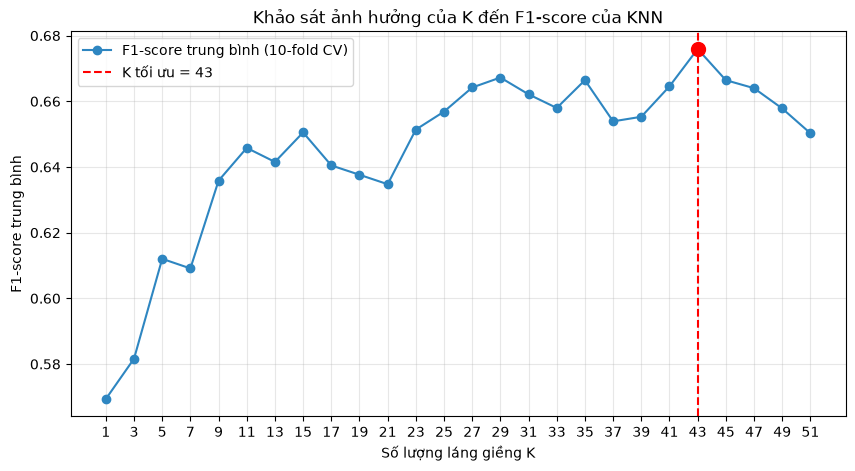

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Tìm K tối ưu bằng 10-fold CV
folds = 10
cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
ks = list(range(1, 52, 2))
cv_scores = []

for k in ks:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    score = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="f1").mean()
    cv_scores.append(score)

optimal_k = ks[cv_scores.index(max(cv_scores))]
best_cv_f1 = max(cv_scores)
print(f"K tối ưu: {optimal_k}")
print(f"F1-score CV tốt nhất: {best_cv_f1:.4f}")

# Biểu đồ khảo sát K
plt.figure(figsize=(10, 5))
plt.plot(ks, cv_scores, marker="o", color="#2E86C1", label="F1-score trung bình (10-fold CV)")
plt.axvline(optimal_k, color="red", linestyle="--", label=f"K tối ưu = {optimal_k}")
plt.scatter(optimal_k, best_cv_f1, color="red", s=100, zorder=3)
plt.title("Khảo sát ảnh hưởng của K đến F1-score của KNN")
plt.xlabel("Số lượng láng giềng K"); plt.ylabel("F1-score trung bình")
plt.xticks(ks); plt.grid(alpha=0.3); plt.legend()
plt.show()


,Train,Test
Accuracy,0.799674,0.740260
Precision,0.757062,0.652174
Recall,0.626168,0.555556
F1-score,0.685422,0.600000


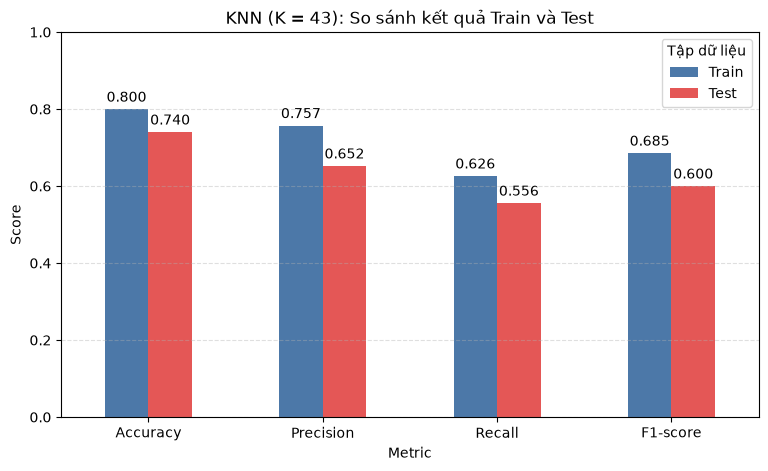

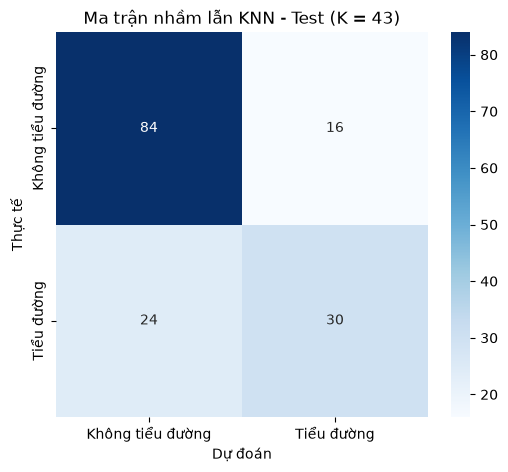

In [17]:
# Huấn luyện KNN với K tối ưu
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=optimal_k))
])
knn.fit(X_train, y_train)
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

metrics_df = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])
display(metrics_df)

ax = metrics_df.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title(f"KNN (K = {optimal_k}): So sánh kết quả Train và Test")
plt.xlabel("Metric"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0); plt.legend(title="Tập dữ liệu")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Không tiểu đường", "Tiểu đường"],
    yticklabels=["Không tiểu đường", "Tiểu đường"])
plt.title(f"Ma trận nhầm lẫn KNN - Test (K = {optimal_k})")
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.show()

accuracy = metrics_df.loc["Accuracy", "Test"]
precision = metrics_df.loc["Precision", "Test"]
recall = metrics_df.loc["Recall", "Test"]
f1 = metrics_df.loc["F1-score", "Test"]
results.append({'Model': 'KNN', 'Accuracy': accuracy,
                'Precision': precision, 'Recall': recall, 'F1-score': f1})


## 12. Mô hình 3 — SVM tuyến tính

/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Train,Test
Accuracy,0.788274,0.720779
Precision,0.759259,0.622222
Recall,0.574766,0.518519
F1-score,0.654255,0.565657


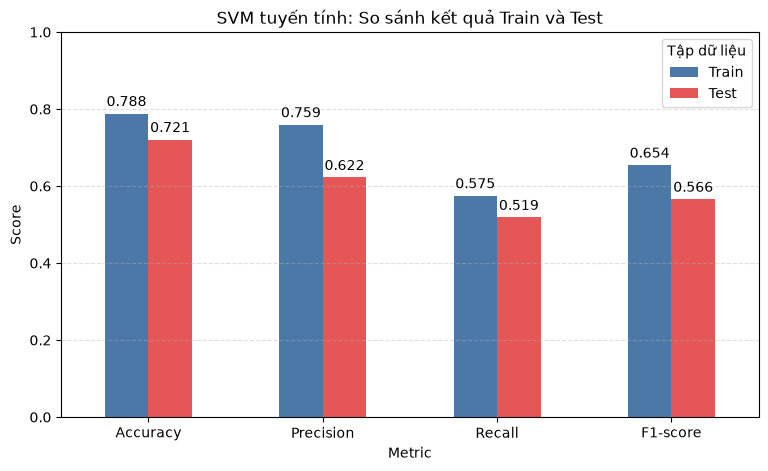

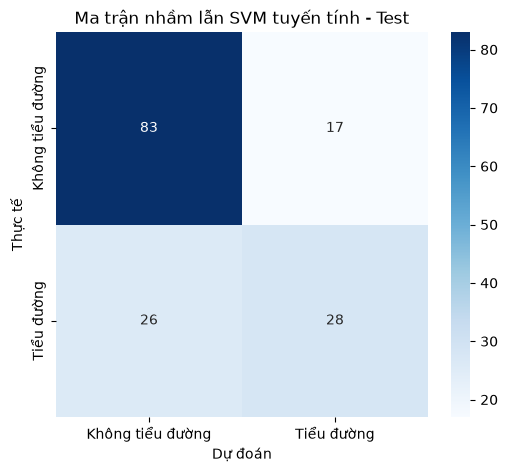

In [18]:
from sklearn.svm import SVC

linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True, random_state=42))
])
linear_svm.fit(X_train, y_train)
y_train_pred = linear_svm.predict(X_train)
y_test_pred = linear_svm.predict(X_test)

metrics_df = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])
display(metrics_df)

ax = metrics_df.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("SVM tuyến tính: So sánh kết quả Train và Test")
plt.xlabel("Metric"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0); plt.legend(title="Tập dữ liệu")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Không tiểu đường", "Tiểu đường"],
    yticklabels=["Không tiểu đường", "Tiểu đường"])
plt.title("Ma trận nhầm lẫn SVM tuyến tính - Test")
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.show()

accuracy = metrics_df.loc["Accuracy", "Test"]
precision = metrics_df.loc["Precision", "Test"]
recall = metrics_df.loc["Recall", "Test"]
f1 = metrics_df.loc["F1-score", "Test"]
results.append({'Model': 'SVM Linear', 'Accuracy': accuracy,
                'Precision': precision, 'Recall': recall, 'F1-score': f1})


## 13. Mô hình 4 — SVM kernel RBF

/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Train,Test
Accuracy,0.802932,0.727273
Precision,0.778443,0.642857
Recall,0.607477,0.500000
F1-score,0.682415,0.562500


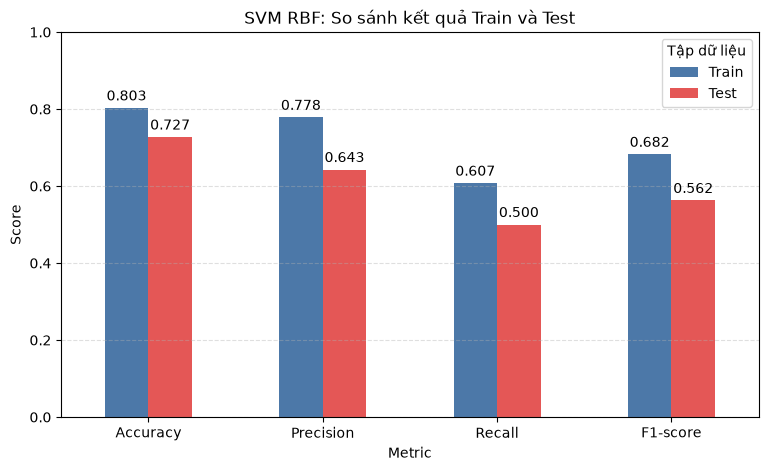

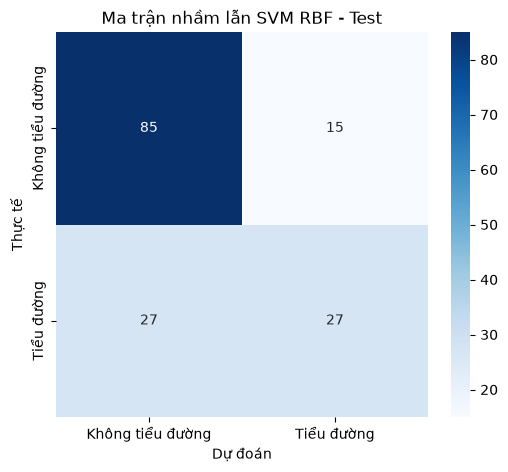

In [19]:
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])
rbf_svm.fit(X_train, y_train)
y_train_pred = rbf_svm.predict(X_train)
y_test_pred = rbf_svm.predict(X_test)

metrics_df = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0)
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])
display(metrics_df)

ax = metrics_df.plot(kind="bar", figsize=(9, 5), color=["#4C78A8", "#E45756"])
plt.title("SVM RBF: So sánh kết quả Train và Test")
plt.xlabel("Metric"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0); plt.legend(title="Tập dữ liệu")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Không tiểu đường", "Tiểu đường"],
    yticklabels=["Không tiểu đường", "Tiểu đường"])
plt.title("Ma trận nhầm lẫn SVM RBF - Test")
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.show()

accuracy = metrics_df.loc["Accuracy", "Test"]
precision = metrics_df.loc["Precision", "Test"]
recall = metrics_df.loc["Recall", "Test"]
f1 = metrics_df.loc["F1-score", "Test"]
results.append({'Model': 'SVM RBF', 'Accuracy': accuracy,
                'Precision': precision, 'Recall': recall, 'F1-score': f1})


## 14. Đánh giá

,Accuracy,Precision,Recall,F1-score
Model,,,,
KNN,0.740,0.652,0.556,0.600
SVM Linear,0.721,0.622,0.519,0.566
SVM RBF,0.727,0.643,0.500,0.562
Logistic Regression,0.708,0.596,0.519,0.554


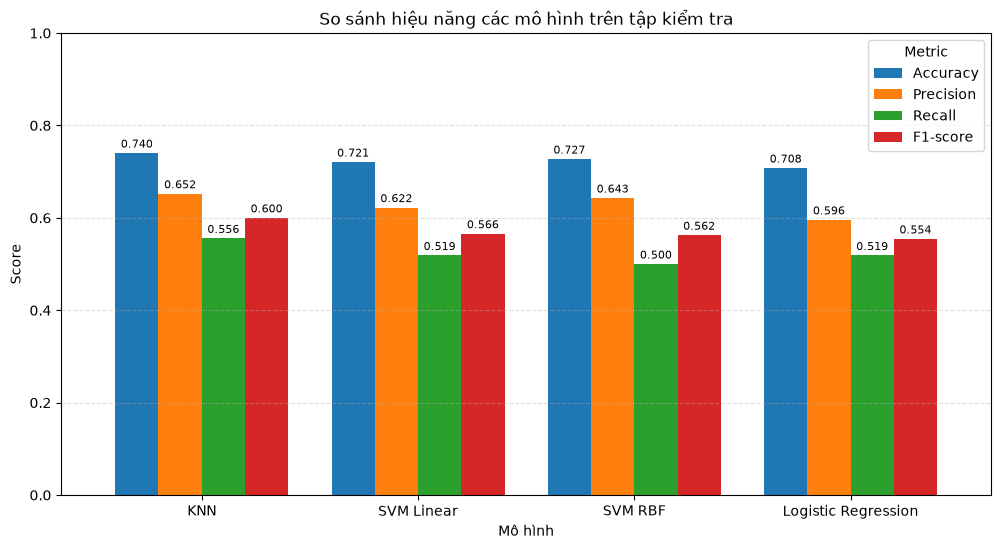

Accuracy cao nhất: KNN (0.740)
Precision cao nhất: KNN (0.652)
Recall cao nhất: KNN (0.556)
F1-score cao nhất: KNN (0.600)


In [20]:
# Bảng so sánh tất cả mô hình
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Model", keep="last")
    .set_index("Model")
)
results_df = results_df.sort_values("F1-score", ascending=False)
display(results_df.style.format("{:.3f}"))

# Biểu đồ so sánh
ax = results_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(12, 6), width=0.8
)
plt.title("So sánh hiệu năng các mô hình trên tập kiểm tra")
plt.xlabel("Mô hình"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
plt.show()

# Xác định mô hình tốt nhất
for metric in ["Accuracy", "Precision", "Recall", "F1-score"]:
    best_model = results_df[metric].idxmax()
    best_score = results_df.loc[best_model, metric]
    print(f"{metric} cao nhất: {best_model} ({best_score:.3f})")


## 15. Điều chỉnh tham số

Phần KNN ở mục 11 đã sử dụng 10-fold cross-validation để chọn K tối ưu. Đây chính là quá trình điều chỉnh siêu tham số (hyperparameter tuning). Kết quả cho thấy K tối ưu đã giúp KNN đạt F1-score cao nhất trong các mô hình.

## 16. Thử với nhiều feature hơn

### 16.1. Chia tập huấn luyện/kiểm tra (6 feature)

In [21]:
# Chia dữ liệu với 6 features
FEATURE_COLUMNS_6 = ["Glucose", "BMI", "Age", "Pregnancies", "SkinThickness", "Insulin"]
TARGET_COLUMN = "Outcome"

X_raw_6, y_6 = df[FEATURE_COLUMNS_6], df[TARGET_COLUMN]
X_train_6, X_test_6, y_train_6, y_test_6 = train_test_split(
    X_raw_6, y_6, test_size=0.20, stratify=y_6, random_state=42
)
print(f"Tập huấn luyện: {X_train_6.shape}; Tập kiểm tra: {X_test_6.shape}")
print("Các cột:", X_train_6.columns.tolist())


Tập huấn luyện: (614, 6); Tập kiểm tra: (154, 6)
Các cột: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness', 'Insulin']


### 16.2. Mô hình 1 — Hồi quy Logistic (6 features)

In [22]:
results_6 = []

log_regress_6 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
log_regress_6.fit(X_train_6, y_train_6)
y_train_pred_6 = log_regress_6.predict(X_train_6)
y_test_pred_6 = log_regress_6.predict(X_test_6)

metrics_df_6 = pd.DataFrame({
    "Train": [
        accuracy_score(y_train_6, y_train_pred_6),
        precision_score(y_train_6, y_train_pred_6, zero_division=0),
        recall_score(y_train_6, y_train_pred_6, zero_division=0),
        f1_score(y_train_6, y_train_pred_6, zero_division=0)
    ],
    "Test": [
        accuracy_score(y_test_6, y_test_pred_6),
        precision_score(y_test_6, y_test_pred_6, zero_division=0),
        recall_score(y_test_6, y_test_pred_6, zero_division=0),
        f1_score(y_test_6, y_test_pred_6, zero_division=0)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])
display(metrics_df_6)

results_6.append({'Model': 'Logistic Regression',
    'Accuracy': metrics_df_6.loc["Accuracy", "Test"],
    'Precision': metrics_df_6.loc["Precision", "Test"],
    'Recall': metrics_df_6.loc["Recall", "Test"],
    'F1-score': metrics_df_6.loc["F1-score", "Test"]})

import pickle
with open('model/logistic_regression.sav', 'wb') as f:
    pickle.dump(log_regress_6, f)


,Train,Test
Accuracy,0.794788,0.714286
Precision,0.755814,0.592593
Recall,0.607477,0.592593
F1-score,0.673575,0.592593


### 16.3. Mô hình 2 — KNN (6 features)

In [23]:
# KNN với 6 features
cv_6 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ks_6 = list(range(1, 52, 2))
cv_scores_6 = []
for k in ks_6:
    knn_pipe_6 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(knn_pipe_6, X_train_6, y_train_6, cv=cv_6, scoring="f1").mean()
    cv_scores_6.append(score)

optimal_k_6 = ks_6[cv_scores_6.index(max(cv_scores_6))]
print(f"K tối ưu (6 features): {optimal_k_6}")

knn_6 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=optimal_k_6))])
knn_6.fit(X_train_6, y_train_6)
y_test_pred_6 = knn_6.predict(X_test_6)

results_6.append({'Model': 'KNN',
    'Accuracy': accuracy_score(y_test_6, y_test_pred_6),
    'Precision': precision_score(y_test_6, y_test_pred_6, zero_division=0),
    'Recall': recall_score(y_test_6, y_test_pred_6, zero_division=0),
    'F1-score': f1_score(y_test_6, y_test_pred_6, zero_division=0)})

import pickle
with open('model/knn.sav', 'wb') as f:
    pickle.dump(knn_6, f)


K tối ưu (6 features): 3


### 16.4. Mô hình 3 — SVM tuyến tính (6 features)

In [24]:
linear_svm_6 = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="linear", probability=True, random_state=42))])
linear_svm_6.fit(X_train_6, y_train_6)
y_test_pred_6 = linear_svm_6.predict(X_test_6)

results_6.append({'Model': 'SVM Linear',
    'Accuracy': accuracy_score(y_test_6, y_test_pred_6),
    'Precision': precision_score(y_test_6, y_test_pred_6, zero_division=0),
    'Recall': recall_score(y_test_6, y_test_pred_6, zero_division=0),
    'F1-score': f1_score(y_test_6, y_test_pred_6, zero_division=0)})

import pickle
with open('model/linear_svm.sav', 'wb') as f:
    pickle.dump(linear_svm_6, f)


/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 16.5. Mô hình 4 — SVM kernel RBF (6 features)

In [25]:
rbf_svm_6 = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=42))])
rbf_svm_6.fit(X_train_6, y_train_6)
y_test_pred_6 = rbf_svm_6.predict(X_test_6)

results_6.append({'Model': 'SVM RBF',
    'Accuracy': accuracy_score(y_test_6, y_test_pred_6),
    'Precision': precision_score(y_test_6, y_test_pred_6, zero_division=0),
    'Recall': recall_score(y_test_6, y_test_pred_6, zero_division=0),
    'F1-score': f1_score(y_test_6, y_test_pred_6, zero_division=0)})

import pickle
with open('model/rbf_svm.sav', 'wb') as f:
    pickle.dump(rbf_svm_6, f)


/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 16.6. Đánh giá (6 features) và so sánh với 3 features

In [26]:
results_6_df = pd.DataFrame(results_6).drop_duplicates(subset="Model", keep="last").set_index("Model")
results_6_df = results_6_df.sort_values("F1-score", ascending=False)

print("=== Kết quả với 6 features ===")
display(results_6_df.style.format("{:.3f}"))

print("\n=== Kết quả với 3 features (từ mục 14) ===")
display(results_df.style.format("{:.3f}"))

# So sánh 3 features vs 6 features
compare_df = pd.DataFrame({
    "3 features - F1": results_df["F1-score"],
    "6 features - F1": results_6_df["F1-score"],
})
compare_df["Chênh lệch"] = compare_df["6 features - F1"] - compare_df["3 features - F1"]
display(compare_df.style.format("{:.3f}"))


=== Kết quả với 6 features ===


,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM RBF,0.831,0.741,0.796,0.768
KNN,0.792,0.704,0.704,0.704
SVM Linear,0.740,0.617,0.685,0.649
Logistic Regression,0.714,0.593,0.593,0.593



=== Kết quả với 3 features (từ mục 14) ===


,Accuracy,Precision,Recall,F1-score
Model,,,,
KNN,0.740,0.652,0.556,0.600
SVM Linear,0.721,0.622,0.519,0.566
SVM RBF,0.727,0.643,0.500,0.562
Logistic Regression,0.708,0.596,0.519,0.554


,3 features - F1,6 features - F1,Chênh lệch
Model,,,
KNN,0.600,0.704,0.104
Logistic Regression,0.554,0.593,0.038
SVM Linear,0.566,0.649,0.083
SVM RBF,0.562,0.768,0.205


## 18. Mô hình cuối cùng

In [27]:
import pickle

# Huấn luyện KNN cuối cùng với K tối ưu trên toàn bộ dữ liệu
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=optimal_k))
])
final_model.fit(X_raw, y)
print(f"Đã huấn luyện model cuối (KNN, K={optimal_k}) trên toàn bộ {len(X_raw)} mẫu")

# Lưu model
filename = "model/diabetes.sav"
with open(filename, "wb") as model_file:
    pickle.dump(final_model, model_file)
print(f"Đã lưu model: {filename}")


Đã huấn luyện model cuối (KNN, K=43) trên toàn bộ 768 mẫu
Đã lưu model: diabetes.sav


In [28]:
# Test với mẫu dữ liệu
with open("model/diabetes.sav", "rb") as model_file:
    loaded_model = pickle.load(model_file)

sample = pd.DataFrame([{"Glucose": 65, "BMI": 70, "Age": 50}])
prediction = loaded_model.predict(sample)
probabilities = loaded_model.predict_proba(sample)
confidence = np.max(probabilities[0]) * 100

print(f"Prediction: {prediction[0]} ({'Tiểu đường' if prediction[0] == 1 else 'Không tiểu đường'})")
print(f"Confidence: {confidence:.2f}%")


Prediction: 1 (Tiểu đường)
Confidence: 55.81%


## 19. Ứng dụng

In [29]:
import requests

def predict_diabetes(BMI, Age, Glucose):
    url = "http://127.0.0.1:8080/diabetes/v1/predict"
    data = {"BMI": BMI, "Age": Age, "Glucose": Glucose}
    response = requests.post(url, json=data, timeout=10)
    response.raise_for_status()
    return response.json()


In [30]:
# Test API (cần chạy REST_API.py trước)
# predictions = predict_diabetes(BMI=30, Age=29, Glucose=100)
# print(predictions)


## 20. Minh hoạ hệ thống

Chạy REST_API.py và truy cập http://localhost:8080 để sử dụng giao diện dự đoán.